# Extract centerlines
This notebook is to extrack centerlines

In [1]:
#import pckgs
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import re

import os
from natsort import natsorted

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

import scipy.fftpack


In [29]:
from centerline.src.make_skeleton import make_skeleton

ModuleNotFoundError: No module named 'centerline'

In [ ]:
import imutils

In [3]:
import os
import pandas as pd
import numpy as np


In [ ]:
#might be that if this is activated matplot lib can't plot
os.environ["DLClight"]="True"
import deeplabcut

### Write bodyparts for config.yaml file


In [4]:
#make bodyparts
n_bodyparts=100
nesting=0
for i in np.arange(0,n_bodyparts):
    if nesting==0: print('- bodypart'+str(i))
    else: print('- - bodypart'+str(i))
    for j in np.arange(1,nesting):
        #only print bodyparts until n_bodyparts
        if i+j<=n_bodyparts:
            print('  - bodypart'+str(i+j))

- bodypart0
- bodypart1
- bodypart2
- bodypart3
- bodypart4
- bodypart5
- bodypart6
- bodypart7
- bodypart8
- bodypart9
- bodypart10
- bodypart11
- bodypart12
- bodypart13
- bodypart14
- bodypart15
- bodypart16
- bodypart17
- bodypart18
- bodypart19
- bodypart20
- bodypart21
- bodypart22
- bodypart23
- bodypart24
- bodypart25
- bodypart26
- bodypart27
- bodypart28
- bodypart29
- bodypart30
- bodypart31
- bodypart32
- bodypart33
- bodypart34
- bodypart35
- bodypart36
- bodypart37
- bodypart38
- bodypart39
- bodypart40
- bodypart41
- bodypart42
- bodypart43
- bodypart44
- bodypart45
- bodypart46
- bodypart47
- bodypart48
- bodypart49
- bodypart50
- bodypart51
- bodypart52
- bodypart53
- bodypart54
- bodypart55
- bodypart56
- bodypart57
- bodypart58
- bodypart59
- bodypart60
- bodypart61
- bodypart62
- bodypart63
- bodypart64
- bodypart65
- bodypart66
- bodypart67
- bodypart68
- bodypart69
- bodypart70
- bodypart71
- bodypart72
- bodypart73
- bodypart74
- bodypart75
- bodypart76
- bodypar

### Generate Centerlines for single planes, and measure performance


In [ ]:
#The cell below find images in a folder and creates an skeleton of them baseed on the h5 on that folder.
#The ouput is saved into a subfolder called centerlines where the X,Y positions are saved, as well as the filename.

2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiff/2020-06-30_16-25-56_chemotaxis_worm2-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
img038048.tif


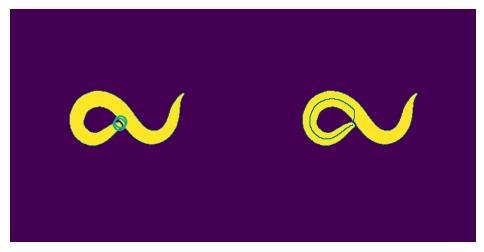

38208
img038208.tif


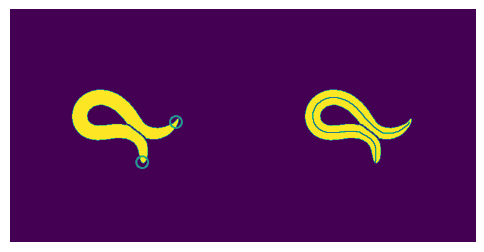

38227
img038227.tif


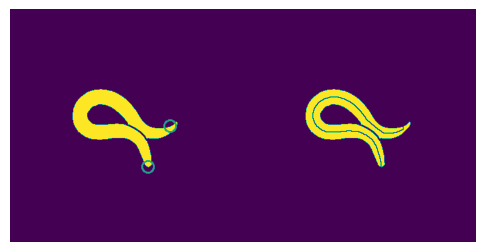

38247
img038247.tif


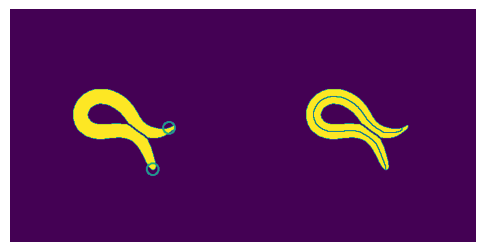

38272
img038272.tif


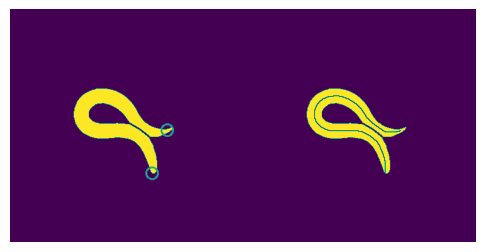

38274
img038274.tif


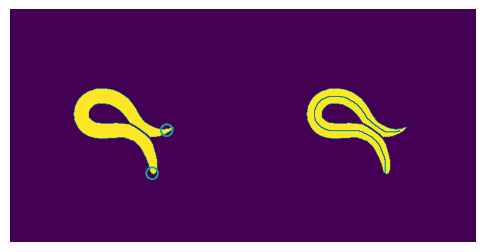

38414
img038414.tif


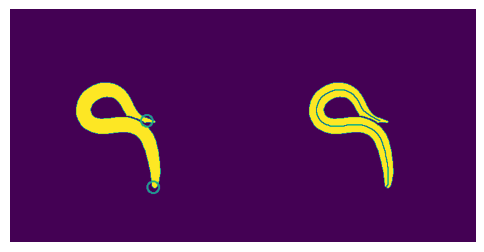

38434
img038434.tif


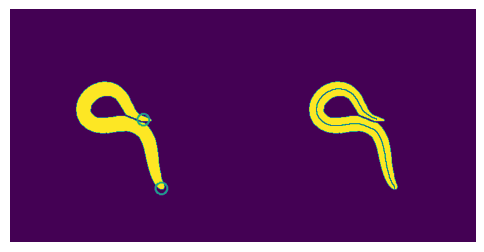

img081443.tif


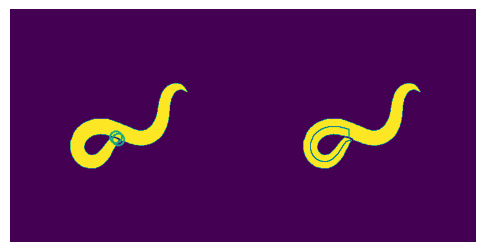

img081753.tif


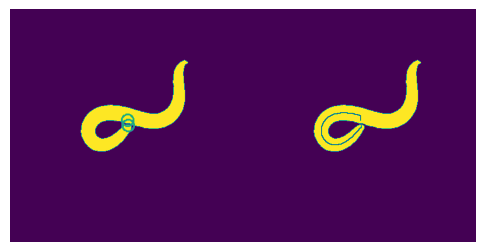

188775
img188775.tif


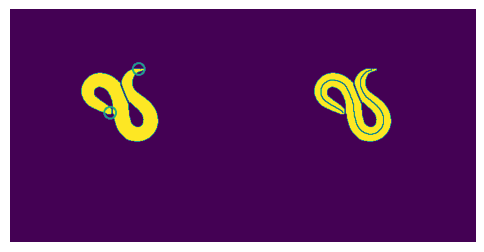

img188899.tif


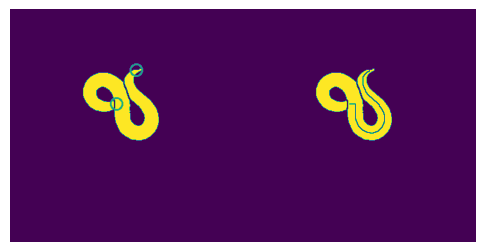

189209
img189209.tif


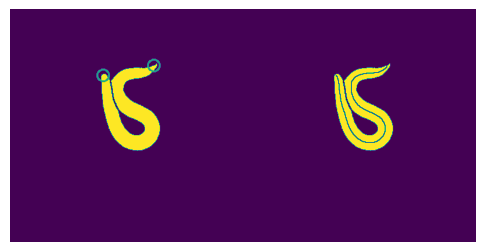

189271
img189271.tif


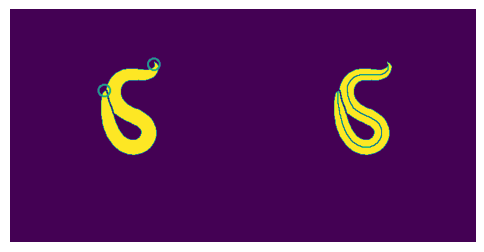

Failed centerlines:  23 
Very short centerlines: 4 
Good centerlines:  10 
Total centerlines:  37
2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff/2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
0
img000000.tif


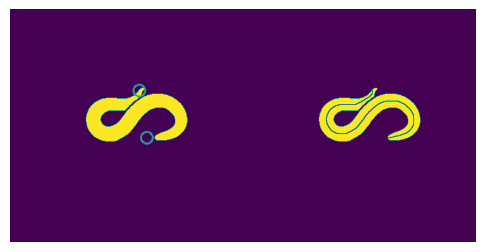

78
img000078.tif


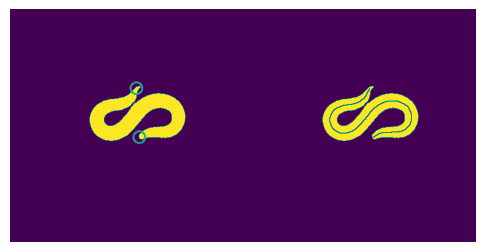

img010324.tif


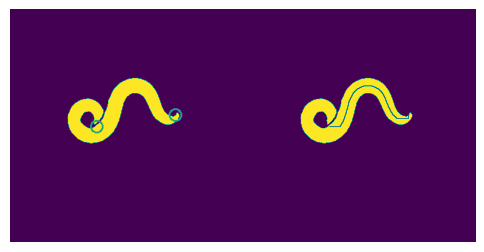

img010437.tif


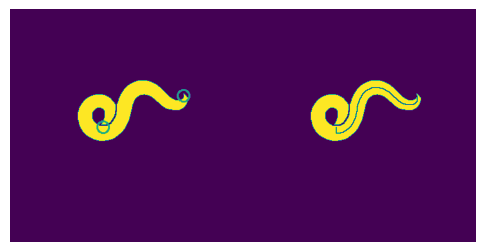

10804
img010804.tif


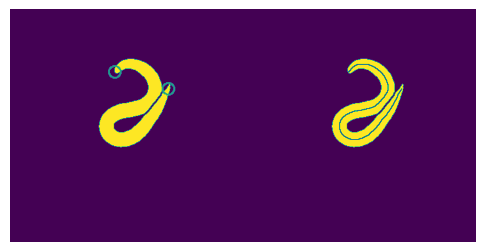

70070
img070070.tif


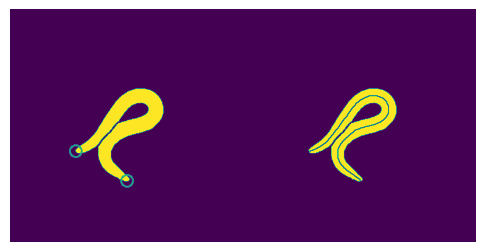

70160
img070160.tif


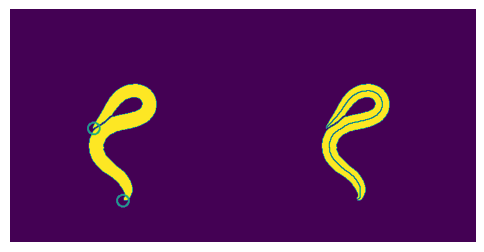

70238
img070238.tif


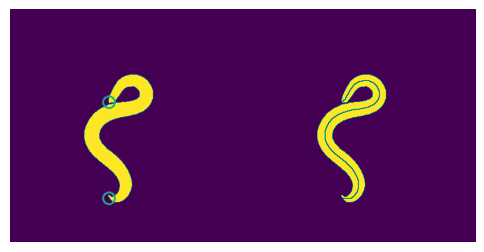

70422
img070422.tif


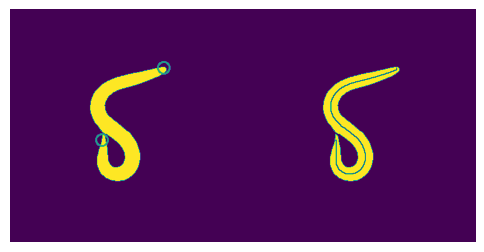

70593
img070593.tif


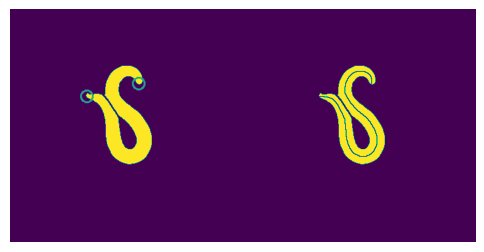

71126
img071126.tif


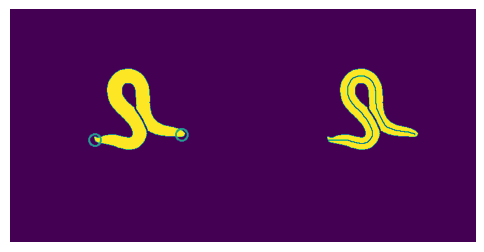

img118293.tif


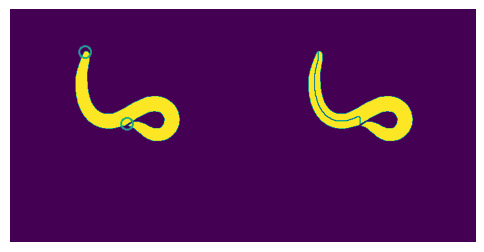

img118307.tif


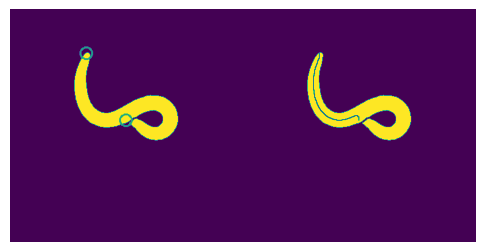

img118374.tif


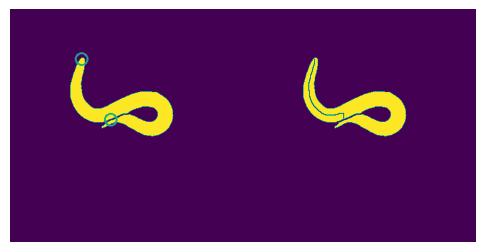

118411
img118411.tif


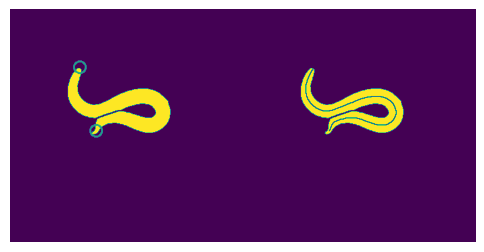

118457
img118457.tif


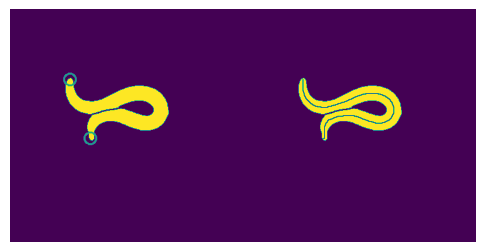

118480
img118480.tif


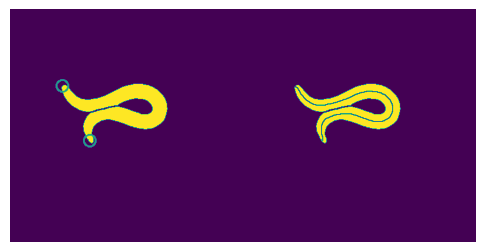

118509
img118509.tif


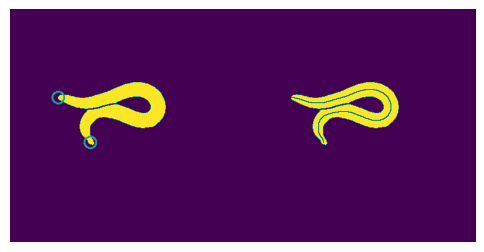

118544
img118544.tif


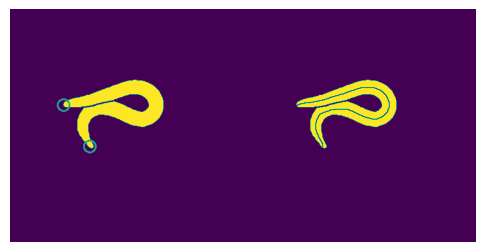

118660
img118660.tif


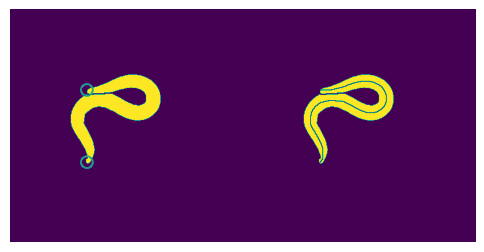

img118712.tif


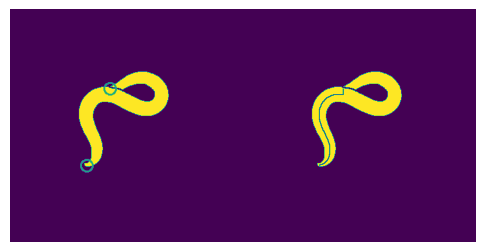

118777
img118777.tif


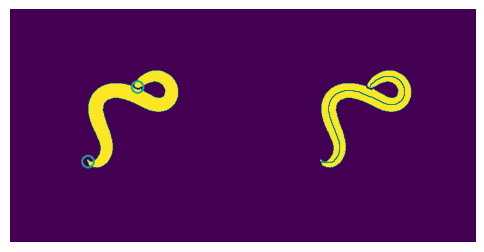

Failed centerlines:  0 
Very short centerlines: 6 
Good centerlines:  16 
Total centerlines:  22
2020-07-01_18-36-25_control_worm6-channel-0-bigtiff
['/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5']
/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/2020-07-01_18-36-25_control_worm6-channel-0-bigtiff/2020-07-01_18-36-25_control_worm6-channel-0-bigtiffDLC_resnet50_HeadTailAug10shuffle1_275000_filtered.h5
1
img000001.tif


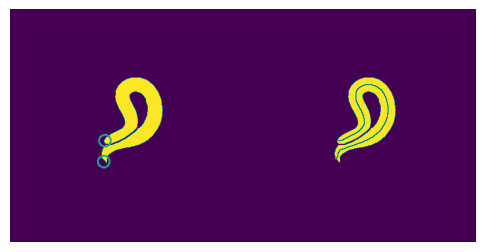

39
img000039.tif


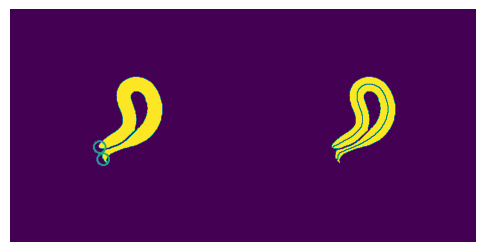

67
img000067.tif


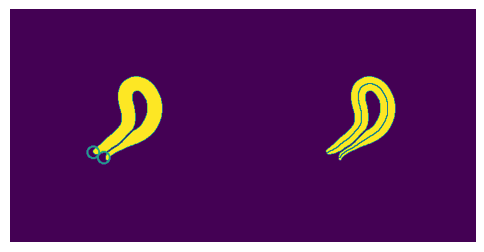

106
img000106.tif


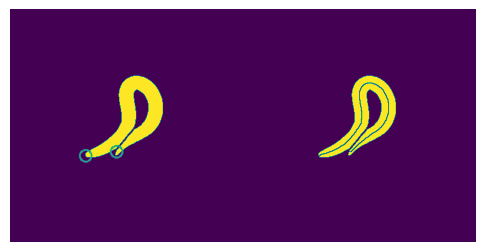

140
img000140.tif


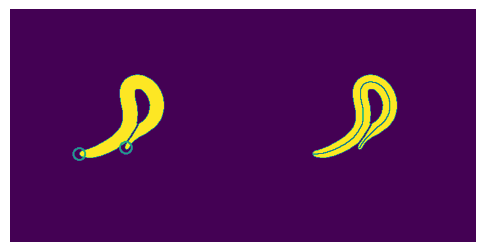

174
img000174.tif


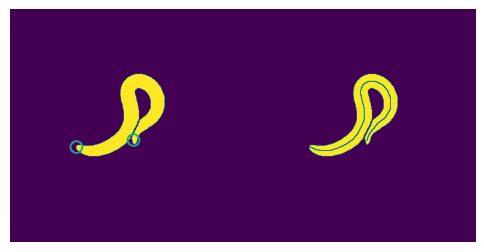

207
img000207.tif


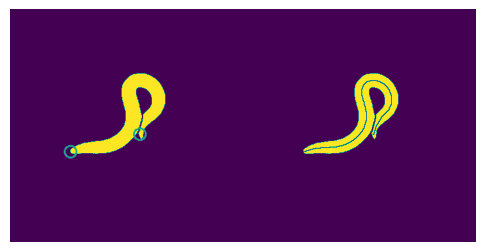

245
img000245.tif


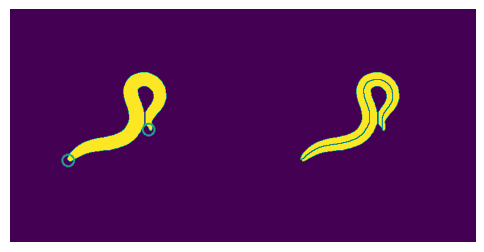

256
img000256.tif


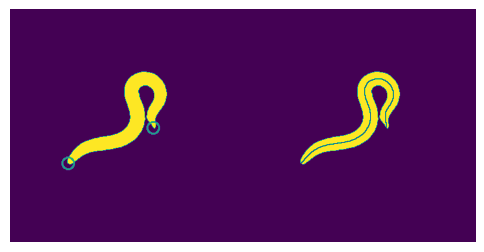

2739
img002739.tif


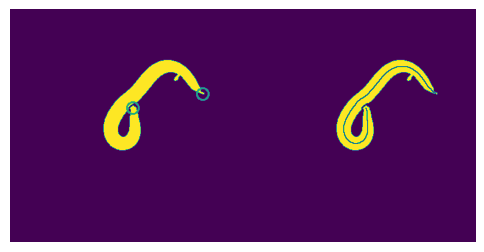

img002754.tif


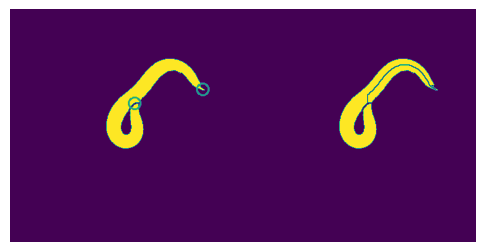

2775
img002775.tif


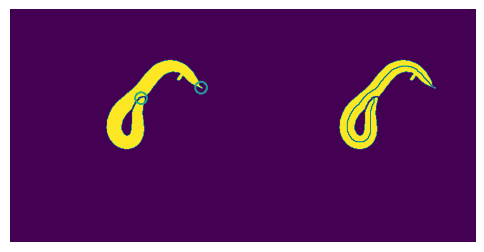

2798
img002798.tif


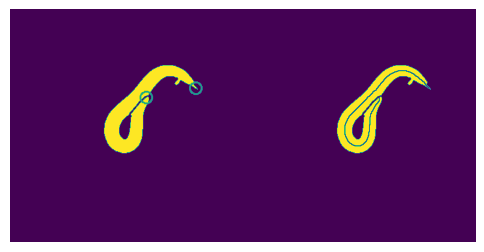

2809
img002809.tif


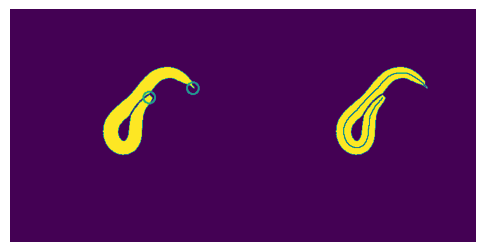

2820
img002820.tif


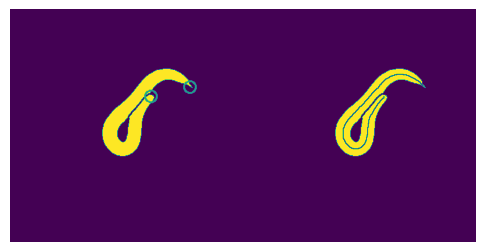

2840
img002840.tif


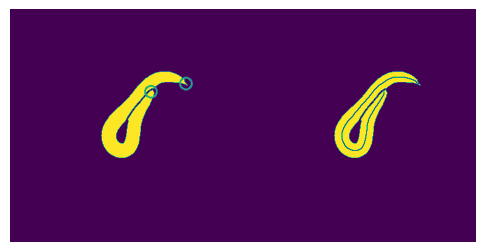

2842
img002842.tif


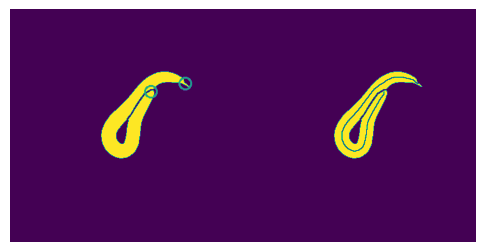

2889
img002889.tif


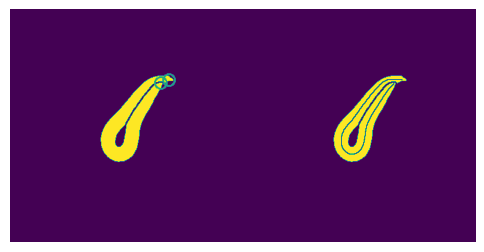

2906
img002906.tif


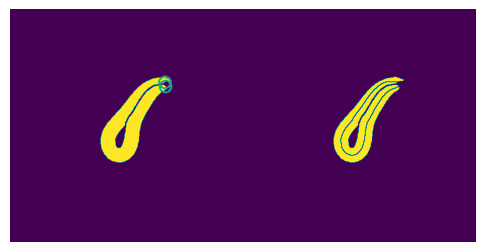

2924
img002924.tif


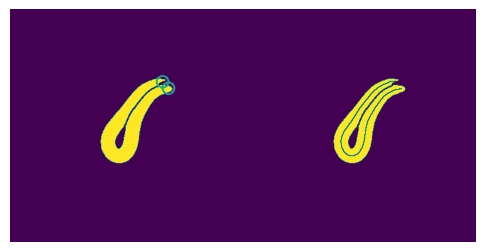

2948
img002948.tif


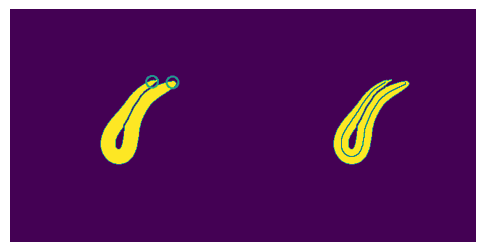

2970
img002970.tif


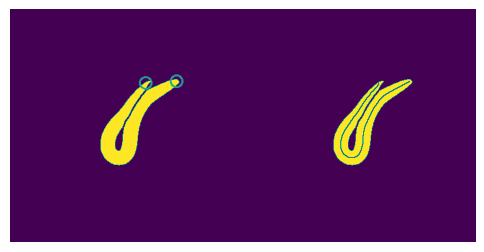

3017
img003017.tif


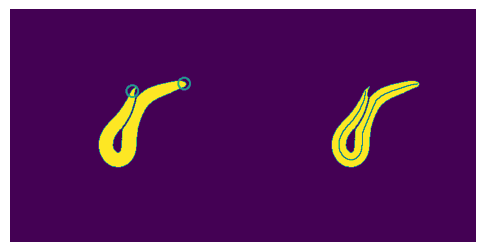

3072
img003072.tif


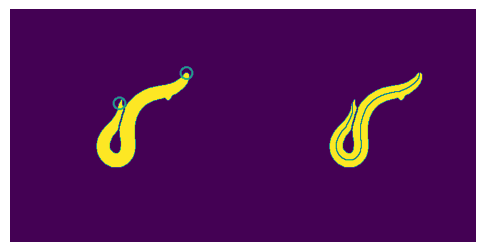

3110
img003110.tif


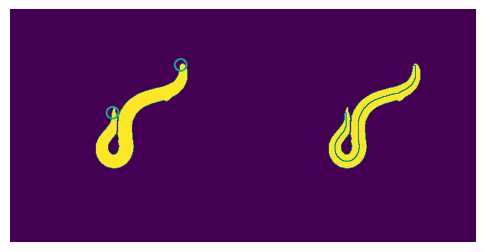

3128
img003128.tif


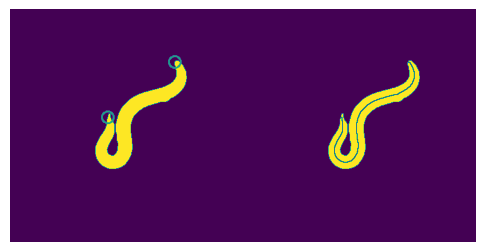

5243
img005243.tif


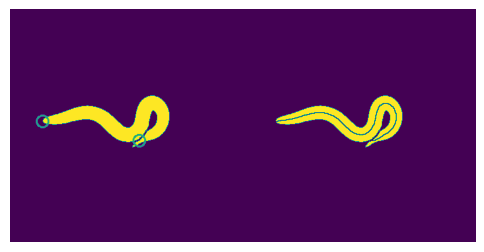

5259
img005259.tif


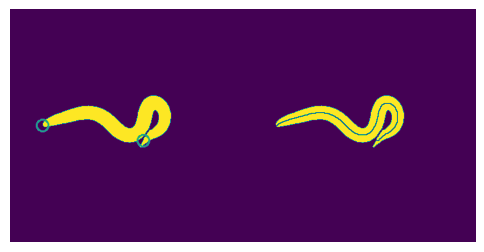

6961
img006961.tif


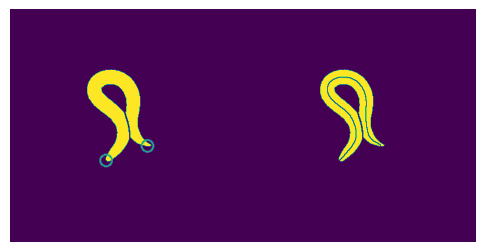

6984
img006984.tif


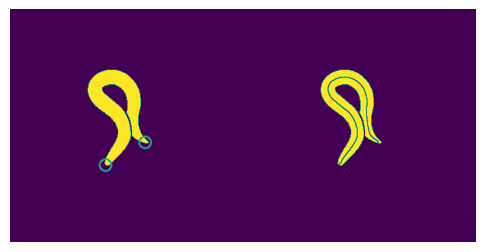

7006
img007006.tif


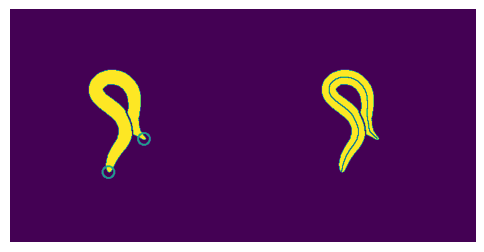

7033
img007033.tif


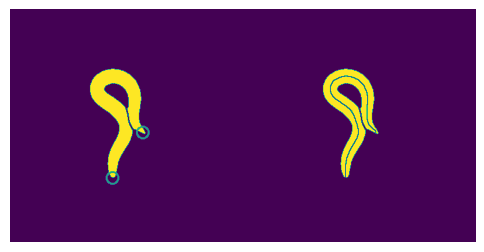

7070
img007070.tif


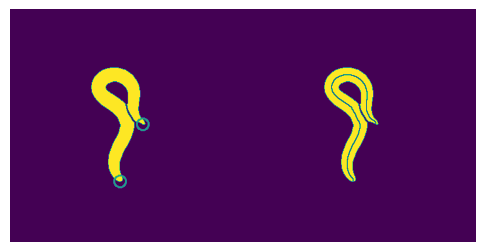

7103
img007103.tif


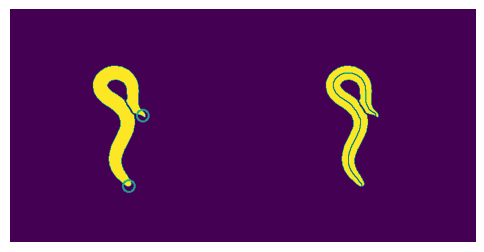

7125
img007125.tif


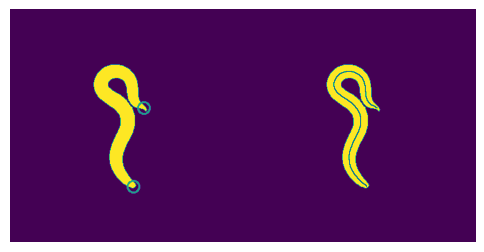

21705
img021705.tif


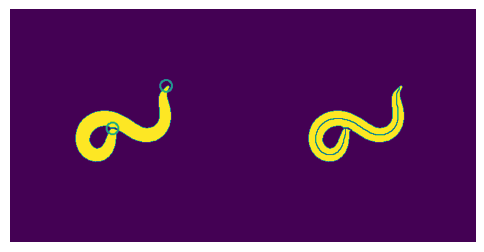

img021745.tif


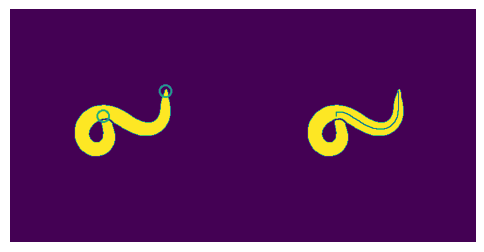

img021775.tif


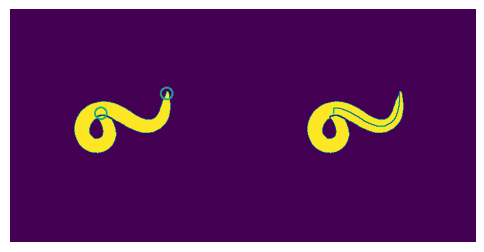

img021805.tif


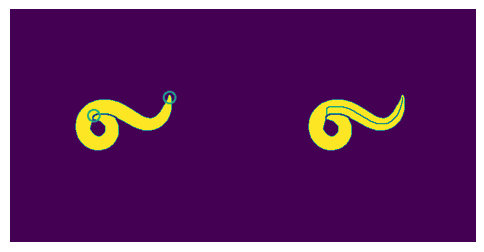

img021834.tif


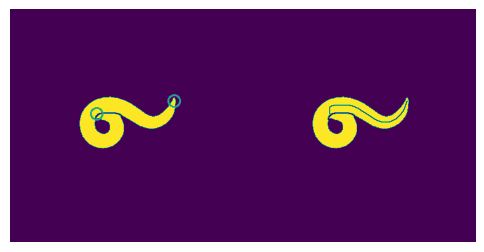

img021901.tif


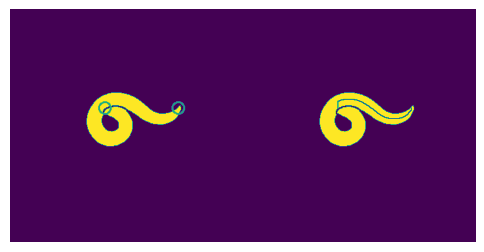

img021944.tif


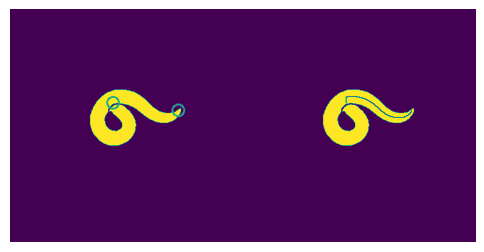

img021966.tif


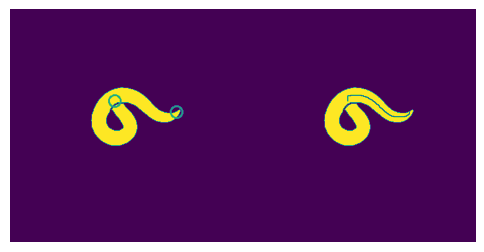

img021974.tif


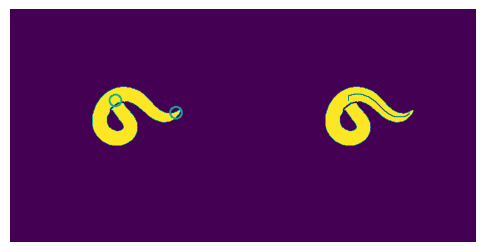

22015
img022015.tif


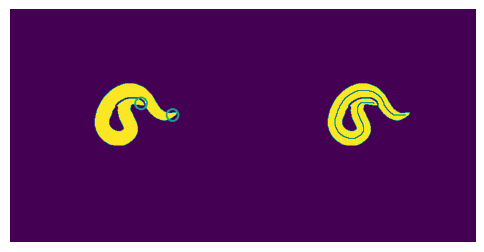

22029
img022029.tif


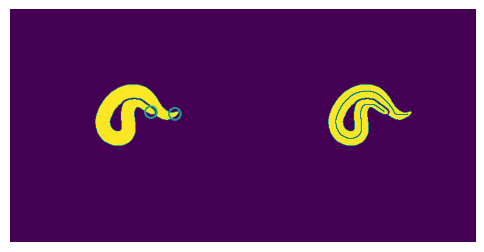

22055
img022055.tif


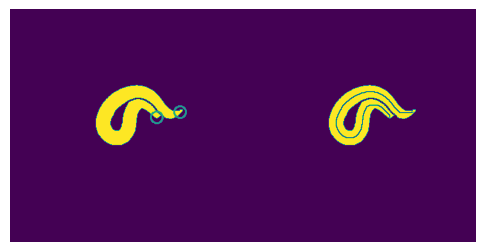

22073
img022073.tif


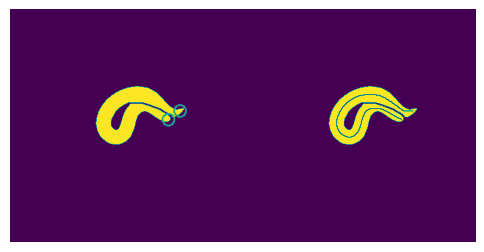

22091
img022091.tif


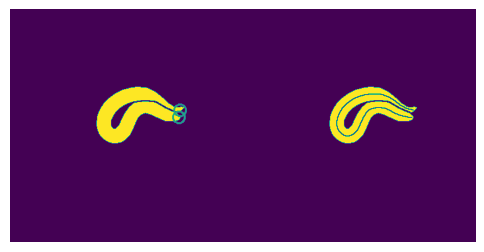

22111
img022111.tif


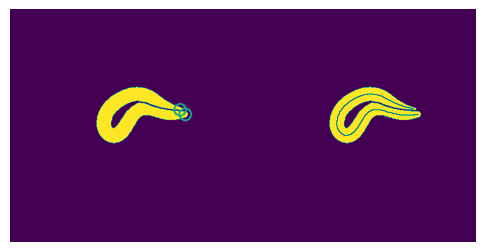

22157
img022157.tif


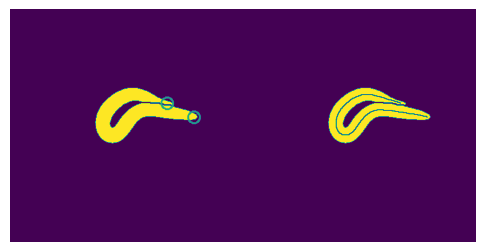

22182
img022182.tif


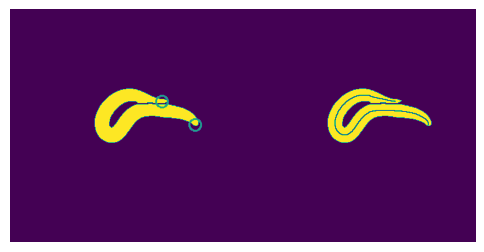

22250
img022250.tif


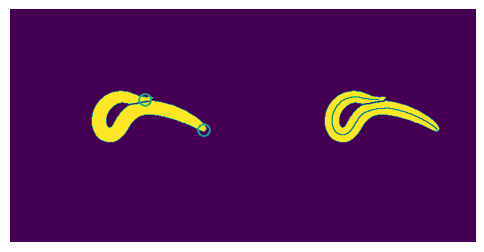

22286
img022286.tif


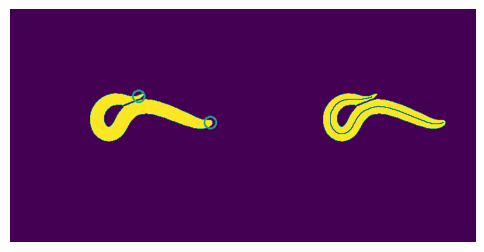

22314
img022314.tif


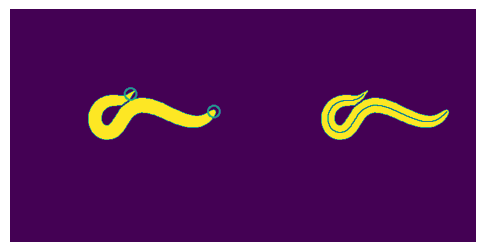

24362
img024362.tif


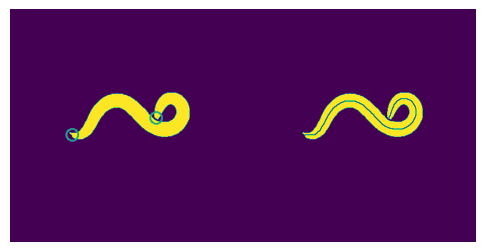

img024414.tif


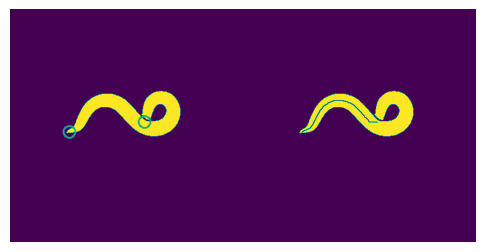

24444
img024444.tif


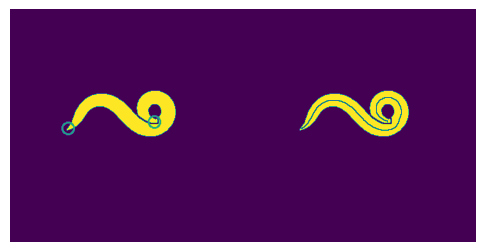

24489
img024489.tif


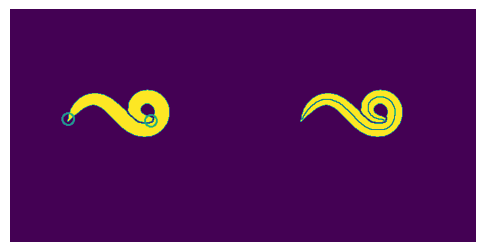

24563
img024563.tif


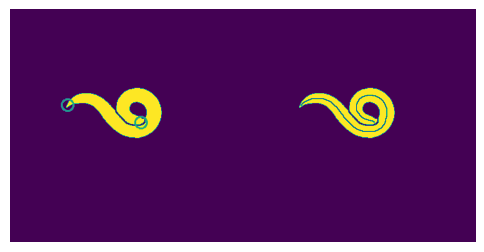

24623
img024623.tif


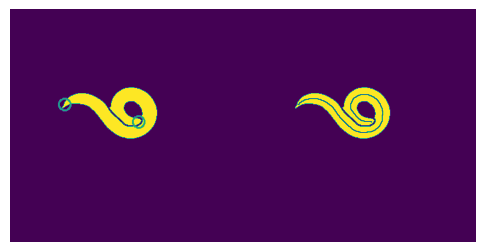

img024683.tif


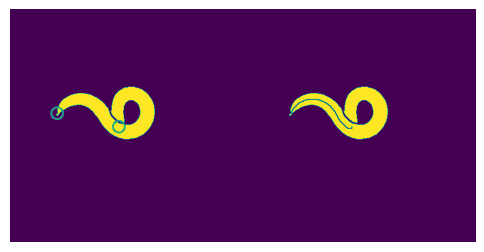

24743
img024743.tif


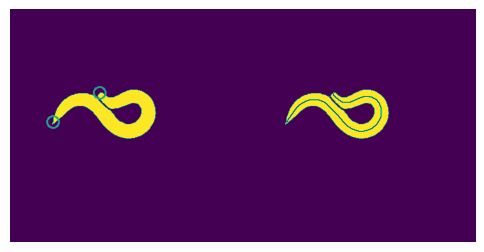

24803
img024803.tif


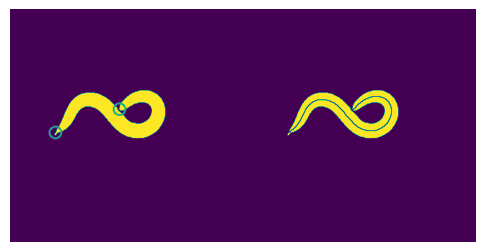

img027739.tif


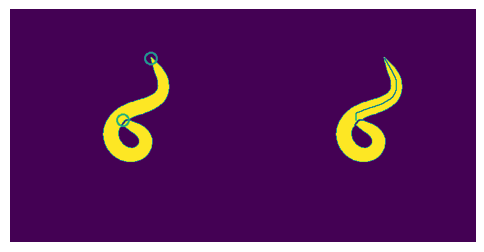

img027799.tif


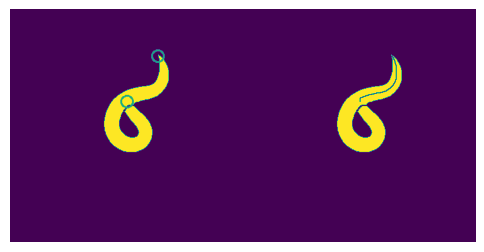

27919
img027919.tif


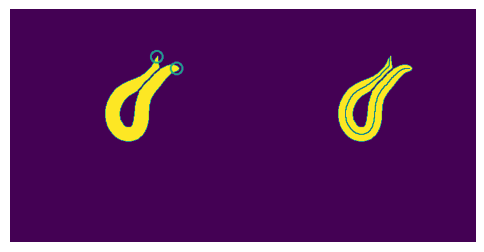

27979
img027979.tif


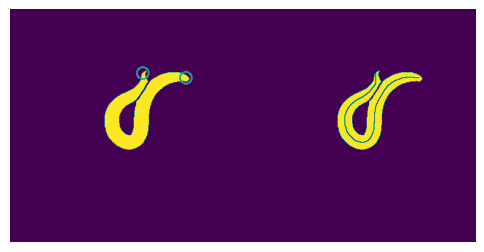

28039
img028039.tif


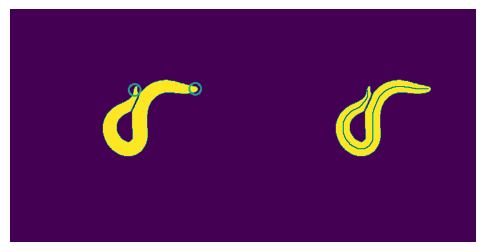

28099
img028099.tif


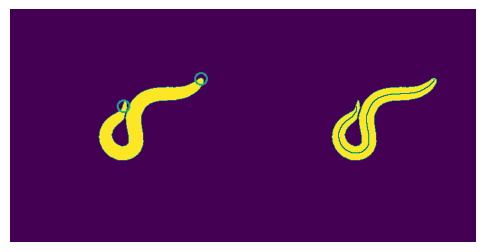

34797
img034797.tif


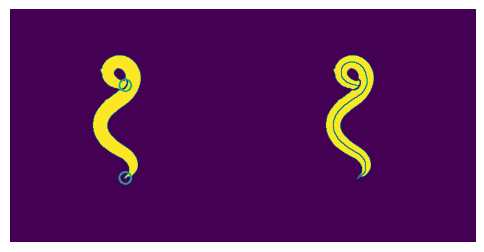

34917
img034917.tif


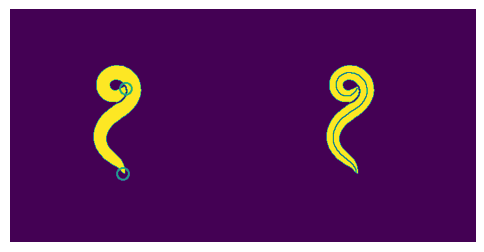

img034977.tif


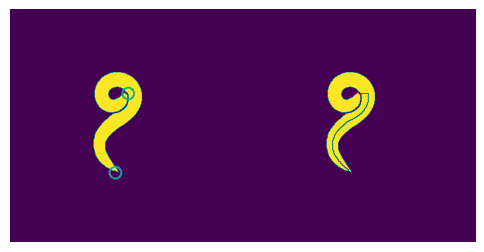

img035037.tif


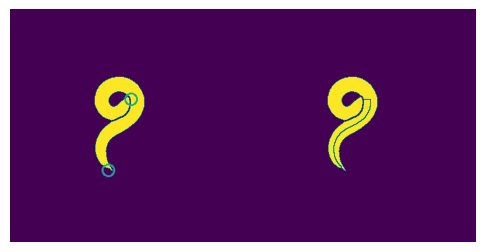

35097
img035097.tif


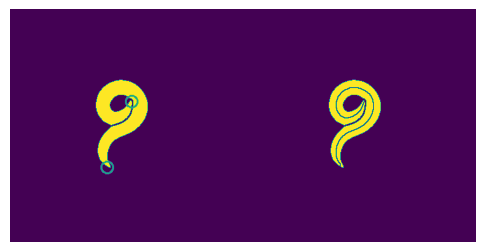

img035157.tif


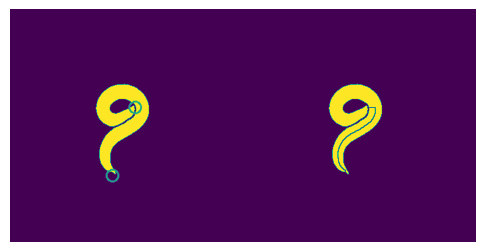

35217
img035217.tif


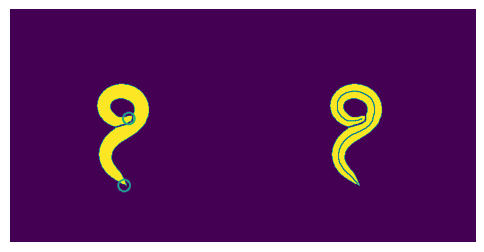

35277
img035277.tif


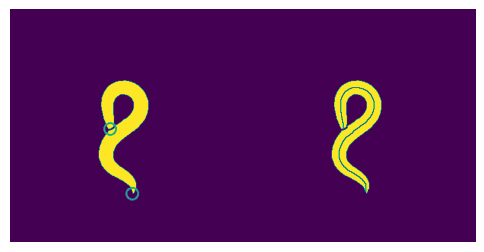

img039862.tif


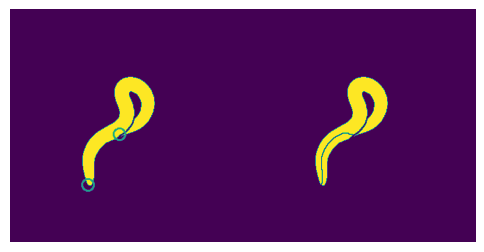

39922
img039922.tif


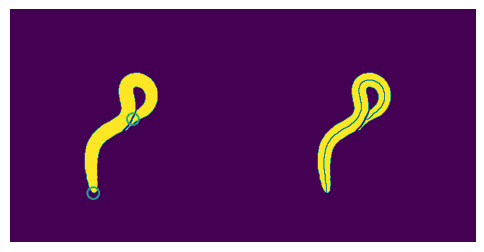

48080
img048080.tif


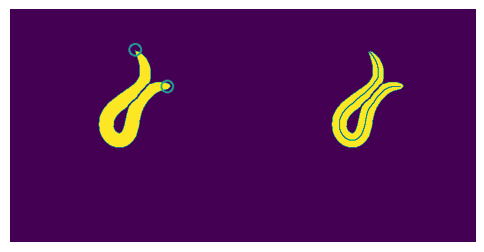

48140
img048140.tif


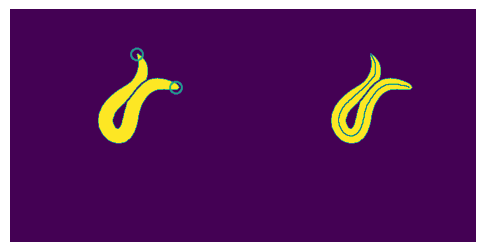

48200
img048200.tif


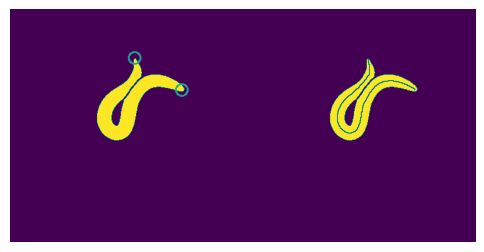

48260
img048260.tif


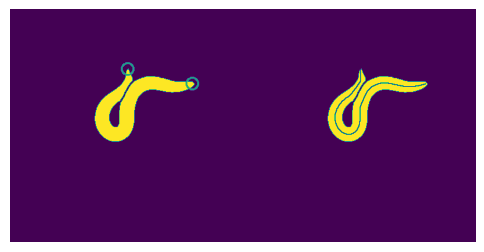

48320
img048320.tif


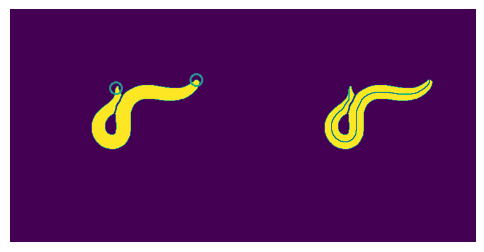

59647
img059647.tif


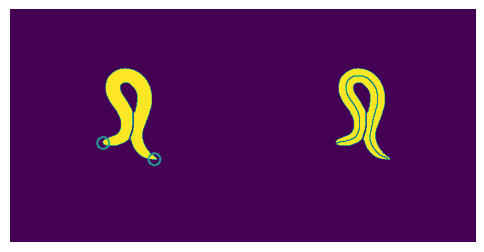

59707
img059707.tif


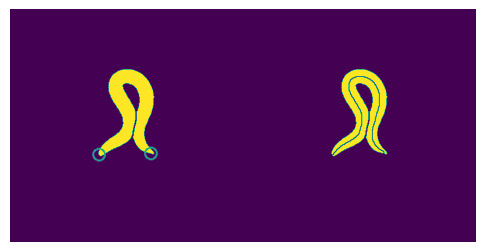

59767
img059767.tif


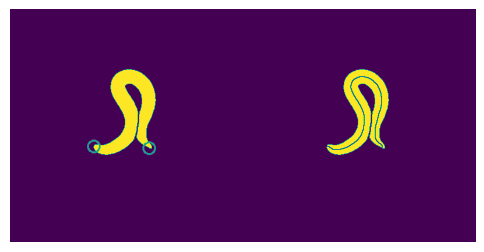

59827
img059827.tif


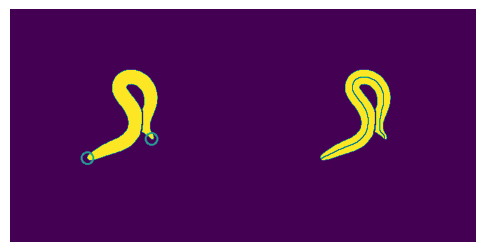

59887
img059887.tif


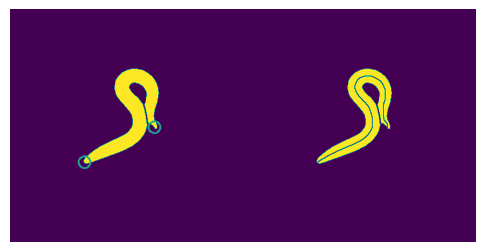

img062763.tif


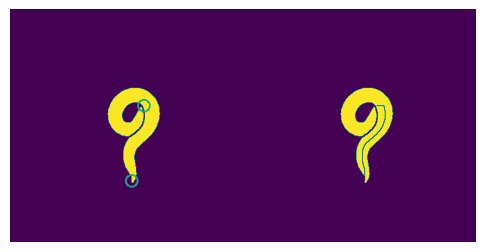

img062823.tif


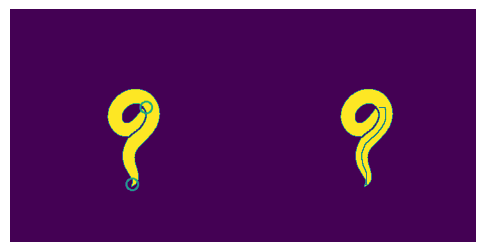

62883
img062883.tif


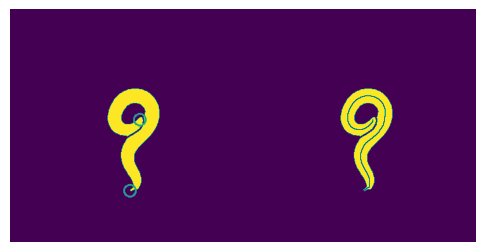

62943
img062943.tif


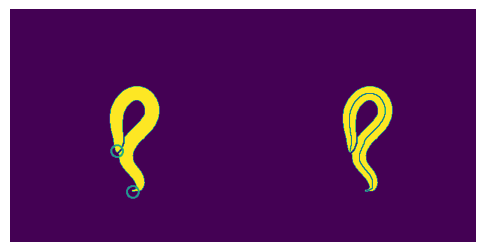

63003
img063003.tif


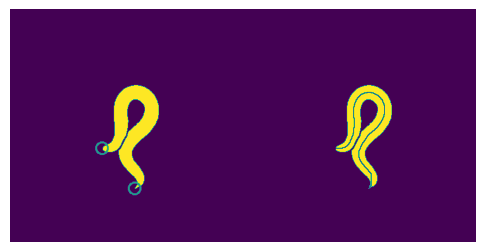

63063
img063063.tif


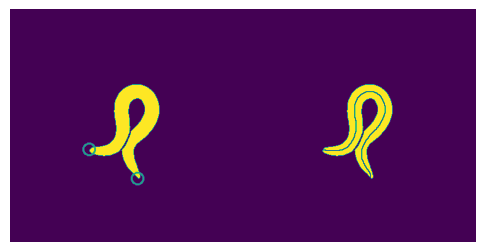

63123
img063123.tif


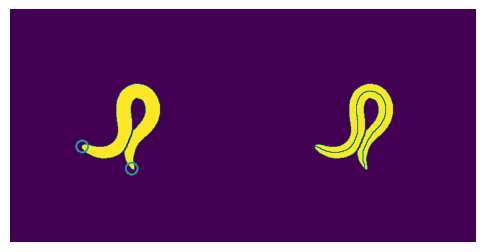

63183
img063183.tif


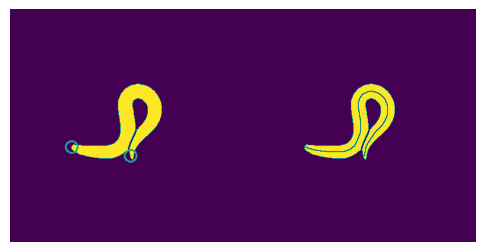

63243
img063243.tif


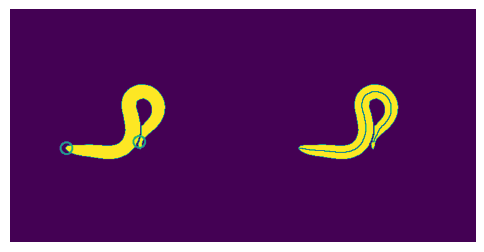

img108725.tif


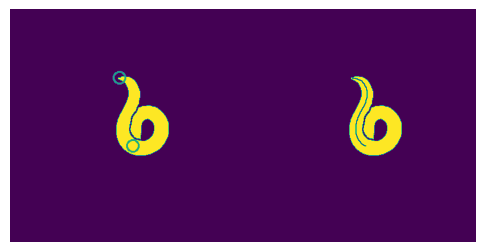

img108845.tif


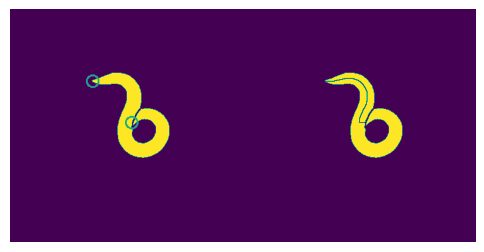

108905
img108905.tif


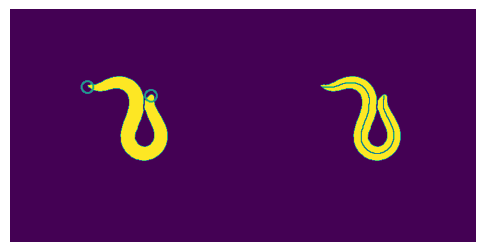

109085
img109085.tif


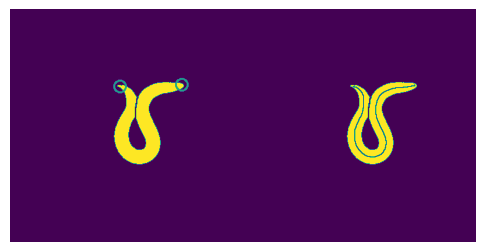

109145
img109145.tif


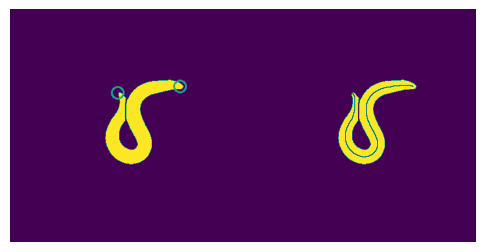

109205
img109205.tif


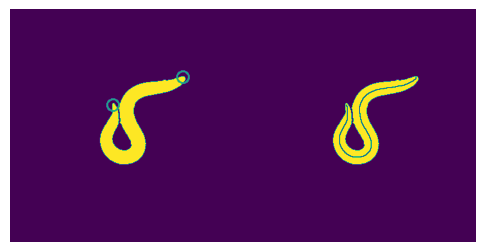

117011
img117011.tif


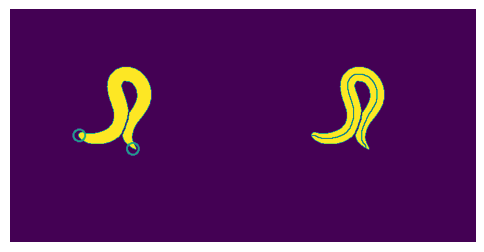

117071
img117071.tif


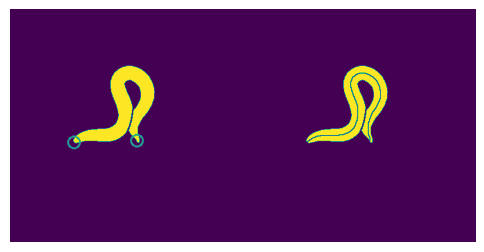

117131
img117131.tif


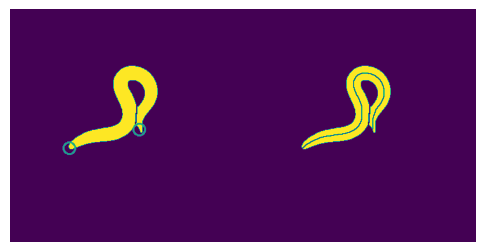

Failed centerlines:  8 
Very short centerlines: 21 
Good centerlines:  87 
Total centerlines:  116
ExtractedData_Ulises_2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.csv
[]


IndexError: list index out of range

In [8]:
import os
import glob

#define number of splines
num_splines=100

#define expected skeleton minimum length
skel_min_length=300

#Compile regular expressions into pattern objects 
regex = re.compile(r'\d+')

main_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/'

for folder in natsorted(os.listdir(main_path)):
    if '.DS' in folder: continue
    print(folder)
    h5_path=glob.glob(os.path.join(main_path,folder)+'/*.h5')
    #print(os.path.join(main_path,folder))
    print(h5_path)
    print(h5_path[0])
    
    df=pd.read_hdf(h5_path[0])
    
    img_path=os.path.join(main_path,folder,'binary_segmented/')
    #print(img_path)
    
    output_path=os.path.join(main_path,folder,'centerlines2/')
    os.makedirs(output_path,exist_ok=True)
    #print(output_path)
    img_list=natsorted(os.listdir(img_path))

    scorer=df.columns.get_level_values(0)[0]
    head_x=df[scorer]['Head']['x'].values
    head_y=df[scorer]['Head']['y'].values
    tail_x=df[scorer]['Tail']['x'].values
    tail_y=df[scorer]['Tail']['y'].values
    
    #create writer object
    csvfileX=open(output_path+'spline_X_coords.csv','w', newline='')
    csvfileX_writer=csv.writer(csvfileX)
    csvfileY=open(output_path+'spline_Y_coords.csv','w', newline='')
    csvfileY_writer=csv.writer(csvfileY)

    csvfilename=open(output_path+'filename.csv','w', newline='')
    csvfilename_writer=csv.writer(csvfilename)
    #set counters for failed centerlines
    c1=0
    c2=0



    for filename in img_list:
        if 'img' in filename:

            #print(filename)
            
            #this int() might be not a good idea, check!
            i=int(regex.search(filename).group(0))
            #print(i)
            start_point=(int(head_y[i]), int(head_x[i]))
            end_point = (int(tail_y[i]), int(tail_x[i]))
            #print(start_point)
            #print(end_point)

            img=tiff.imread(os.path.join(img_path,filename))

            annotated_img=img.copy()
            cv2.circle(annotated_img,(int(head_x[i]), int(head_y[i])),10, (150,150,150), 2)
            cv2.circle(annotated_img,(int(tail_x[i]), int(tail_y[i])),10, (150,150,150), 2)

    #         plt.figure(figsize=(10,10), dpi=150)
    #         plt.subplot(1,2,1)
    #         plt.imshow(annotated_img)

            u, skel_coords, spline_coords, K=make_skeleton(start_point, end_point,num_splines, img)
            #print(skel_coords[0].shape)

            #try to unpack the skel_coords as an array of int (will fail if skel_coords contains NaN)
            try: coords=np.asarray(list(zip(*skel_coords)), dtype=int)# the dtype=int makes sures no NaN can be passed, which will cause trouble when indexing
            except:
                c1=c1+1
                #print('head and tail were too close, no centerline could be created', c1)

            else:
                #counter for short skel coords
                if len(skel_coords[0])<=skel_min_length:
                    c2=c2+1
                    #print('short centerline', c2)

                #draw zeros on the skel_img where the are coordinates
                skel_img=img.copy()
                for idx,coords in enumerate(coords):
                    skel_img[coords[0],coords[1]]=0

                #save coordinates of the good centerlines
                if len(skel_coords[0])>skel_min_length:
                    print(i)
                    x,y=np.asarray(spline_coords)
                    csvfileX_writer.writerow(x)
                    csvfileY_writer.writerow(y)
                    #would [filename] alone work? filename without[] writes every letter in a different cell
                    csvfilename_writer.writerow([os.path.join('labeled-data',folder,filename)])#(['filename:',filename])
                #plotting
                ##if i!=0: continue
                print(filename)
                #plt.figure(figsize=(10,10), dpi=100)
                
                
                fig, axes = plt.subplots(nrows=1, ncols=2, dpi=100)
                axes[0].imshow(annotated_img)
                axes[1].imshow(skel_img)
                #axes[0].set_aspect('equal')
                for ax in axes:
                    ax.set_xlim(100, 500)
                    ax.set_ylim(100, 500)
                    ax.axis('off')
                #axes[1].axis('off')
                #axes[1].set_aspect('equal')
                fig.subplots_adjust(wspace=0, hspace=0)
                plt.show()
                #break
                #check if the skel_coords are too short
    csvfileX.close()
    csvfileY.close()
    csvfilename.close()
    print('Failed centerlines: ', c1,'\nVery short centerlines:', c2, '\nGood centerlines: ', len(img_list)-c1-c2,'\nTotal centerlines: ', len(img_list))



# This code was in OT_annotator.ipynb notebook before

Part of this pipeline, or the entire one should be transfered to Skeleton_cluster or to a new notebook designed for this.

In [5]:
#make a list of strings with X0, X1..X99, and same with Y
Xlist_of_strings=[]
Ylist_of_strings=[]
XYlist_of_strings=[]



for i in np.arange(100): #100 body parts
    Xstring=(str(i)+'X')
    #print(string)
    Xlist_of_strings.append(Xstring)
    
    Ystring=(str(i)+'Y')
    #print(string)
    Ylist_of_strings.append(Ystring)

    #not used I think, would be useful if x,y where saved in same csv file
    XYlist_of_strings.append(Xstring)
    XYlist_of_strings.append(Ystring)

In [6]:
#load data with names list_of_strings
#csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/Annotation_OT/to_plot_centerlines_figures_labmeeting19/centerlines/'
csv_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/2020-07-01_10-50-18_control_worm2_segmented_'
#ATTENTION, we load spline_X_coords with names Y because DLC has X and Y inverted
X_df=pd.read_csv(csv_path+'spline_X_coords.csv', header=None, names=Ylist_of_strings)#I cant put dtype=int here because names are strings
Y_df=pd.read_csv(csv_path+'spline_Y_coords.csv', header=None, names=Xlist_of_strings)

In [7]:
X_df.head(50)
#X_df.tail(20)

,0Y,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,...,90Y,91Y,92Y,93Y,94Y,95Y,96Y,97Y,98Y,99Y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


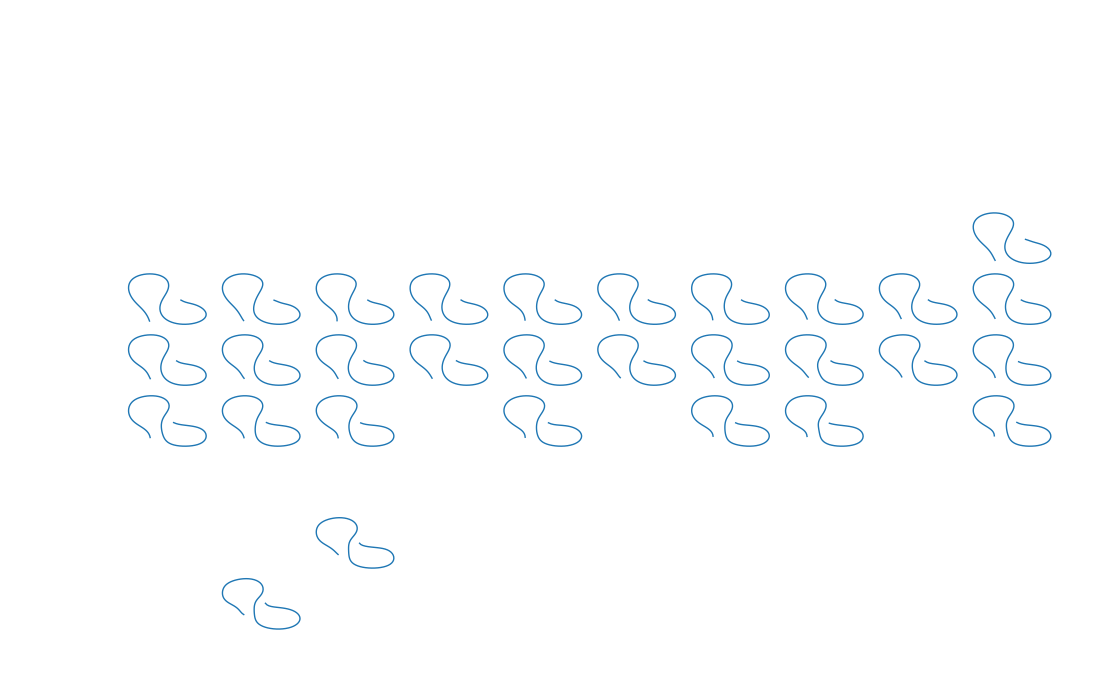

In [8]:
fig, axes = plt.subplots(nrows=10, ncols=10, dpi=200)
i=0
for row in np.arange(10):
    for col in np.arange(10):
        #print('row: ', row, 'col: ', col)
        #print(X_df.loc[i])
        axes[row][col].plot(X_df.loc[i].values,Y_df.loc[i].values, linewidth=0.5)
        axes[row][col].axis('off')
        i=i+1
        #print(i)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

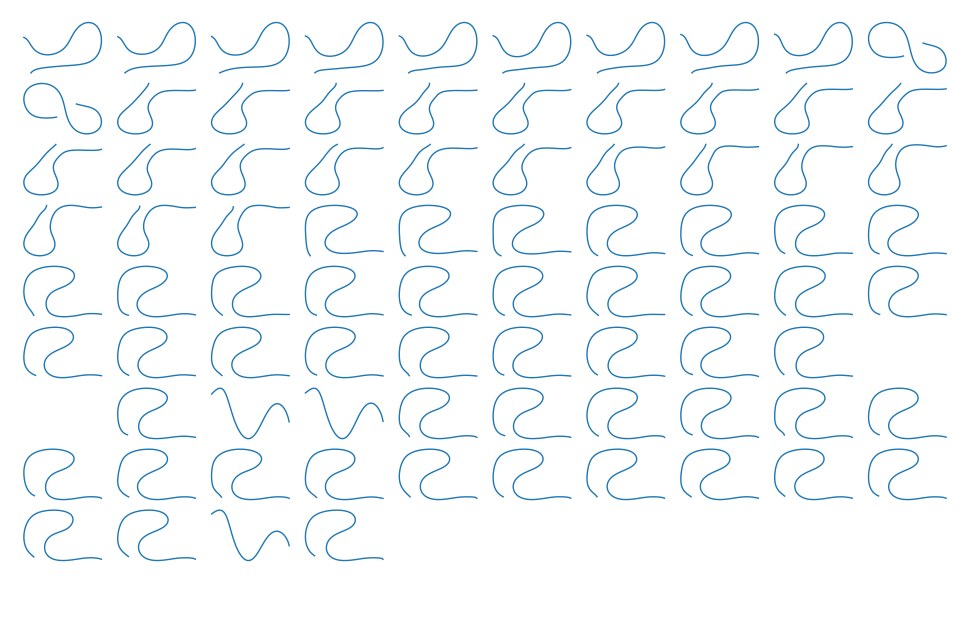

In [23]:
fig, axes = plt.subplots(nrows=10, ncols=10, dpi=200)
i=0
for row in np.arange(10):
    for col in np.arange(10):
        axes[row][col].plot(X_df.loc[i],Y_df.loc[i], linewidth=0.5)
        axes[row][col].axis('off')
        i=i+1
#        print(i)
fig.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

In [ ]:
#if you want to draw centerline on top of the worm, run function below

In [16]:
input_filename='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/btf_all/2020-07-01_10-10-48_control_worm1-channel-0-bigtiff.btf'

with tiff.TiffFile(input_filename, multifile=False) as tif:
    for i, page in enumerate(tif.pages):
        if i not in frames :continue#print(i)
        print(i)
        img=page.asarray()
        img=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
        for idx, K_value in enumerate(X_df.iloc[i]):
            #if there are nans (centerline does not exist, continue)
            if np.isnan(X_df.iloc[i][idx])==True: continue
            x=int(X_df.iloc[i][idx])
            y=int(Y_df.iloc[i][idx])  

            #normalize k value to 255, important to do it. 0.03 is close to the max value
            K_value=K_value/0.03*255

            cv2.circle(img,(y,x), 3, (K_value,0,-K_value),-1)

        plt.imshow(img)
        plt.show()

        if i==1: break       

NameError: name 'frames' is not defined

In [19]:
X_df.head(50)

,0Y,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,...,90Y,91Y,92Y,93Y,94Y,95Y,96Y,97Y,98Y,99Y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
Y_df.head(15)

,0X,1X,2X,3X,4X,5X,6X,7X,8X,9X,...,90X,91X,92X,93X,94X,95X,96X,97X,98X,99X
0,278.175805,280.187105,281.723054,282.896044,283.798347,284.504108,285.071337,285.543902,285.953519,286.321746,...,312.014014,313.992139,316.141683,318.417843,320.764339,323.112100,325.377952,327.463308,329.252855,330.613242
1,278.367933,280.060358,281.493634,282.703292,283.720954,284.574626,285.288984,285.885665,286.383556,286.799085,...,312.569686,314.466555,316.552534,318.792540,321.138412,323.526722,325.876571,328.087394,330.036763,331.578189
2,280.421142,281.504124,282.498081,283.403620,284.221926,284.954780,285.604581,286.174364,286.667819,287.089313,...,312.774598,314.707709,316.824939,319.089688,321.453237,323.852934,326.210377,328.429605,330.395280,331.970871
3,280.114124,281.713239,282.823442,283.585251,284.110956,284.487609,284.780017,285.033731,285.278038,285.528952,...,313.162608,315.368883,317.711694,320.141707,322.600339,325.019142,327.319183,329.410431,331.191141,332.547237
4,279.862673,281.399128,282.417664,283.094025,283.564291,283.929363,284.259437,284.598491,284.968755,285.375199,...,312.895487,315.155697,317.572758,320.090260,322.638773,325.134661,327.478900,329.555889,331.232271,332.355741
5,280.320663,281.646307,282.558034,283.189899,283.646448,284.006016,284.324035,284.636330,284.962425,285.308847,...,312.859551,315.145381,317.570879,320.082218,322.614928,325.093146,327.428875,329.521237,331.255730,332.503479
6,278.829880,280.324590,281.473446,282.376045,283.110024,283.733577,284.287968,284.800052,285.284786,285.747750,...,313.243970,315.533587,317.970732,320.497711,323.044733,325.529030,327.853972,329.908189,331.564682,332.679948
7,277.554307,279.429723,280.701209,281.569359,282.189816,282.678341,283.115881,283.553635,284.018124,284.516258,...,313.318786,315.727000,318.274712,320.901573,323.535255,326.090653,328.469090,330.557522,332.227744,333.335592
8,277.661108,279.237090,280.437345,281.366889,282.108373,282.724615,283.261129,283.748653,284.205677,284.640973,...,313.237239,315.639499,318.190755,320.835037,323.502963,326.110328,328.556691,330.723969,332.475026,333.652259
9,281.797380,280.837138,280.108732,279.586331,279.256835,279.117728,279.174946,279.440736,279.931511,280.665720,...,294.074331,295.836489,297.306287,298.539328,299.600021,300.556512,301.475614,302.417739,303.431824,304.550267


In [20]:
#concat on the axis=1 the two df
all_df=pd.concat([X_df,Y_df], axis=1)

In [21]:
all_df.head(3)

,0Y,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,...,90X,91X,92X,93X,94X,95X,96X,97X,98X,99X
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
#to reindex the columns in the correct order
all_df=all_df.reindex(columns=natsorted(all_df.columns))
    #df.reindex(index=natsorted(df.index))

In [108]:
#as a matter of fact DLC accepts sub pixel resolution, there is no need to covnert to int
#all_df=all_df[:].astype(int)

In [24]:
all_df.head(50)

,0X,0Y,1X,1Y,2X,2Y,3X,3Y,4X,4Y,...,95X,95Y,96X,96Y,97X,97Y,98X,98Y,99X,99Y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
print(os.path.join(main_path,folder))

NameError: name 'main_path' is not defined

In [ ]:
#Save extracted data into a csv file

In [184]:
all_df.to_csv(os.path.join(main_path,'ExtractedData_Ulises_2020-07-01_13-21-00_chemotaxisl_worm1-channel-0-bigtiff.csv'))

In [25]:
save_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/wrong_centerlines_binary/2020-07-01_10-50-18_control_worm2_segmented_ExtractedData_Ulises.csv'
all_df.to_csv(save_path)

In [ ]:
# Open DLC,

In [27]:
config_filepath='/groups/zimmer/Ulises/code/deeplabcut_projects/2020-07-01_10-50-18_control_worm2-Ulises-2021-04-18/config.yaml'
deeplabcut.convertcsv2h5(config_filepath, userfeedback=False)